In [19]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10,6)

df = pd.read_csv('cleaned_train.csv')


# Show all rows
pd.set_option('display.max_rows', None)

# Show all columns
pd.set_option('display.max_columns', None)

# Show full content inside each cell (no text truncation)
pd.set_option('display.max_colwidth', None)

# Prevent wrapping to a new line
pd.set_option('display.width', None)

# Dataset Overview

In [6]:
print("Shape of Dataset :", df.shape)

display(df.head())

display(df.info())

Shape of Dataset : (1460, 219)


,Unnamed: 0.1,Unnamed: 0,Id,MSSubClass,LotFrontage,LotArea,Utilities,LandSlope,OverallQual,OverallCond,...,HasPorch,OutdoorLuxury,HasPool,BsmtFinishedRatio,HasFinishedBsmt,BasementScore,OverallScore,ExteriorScore,LuxuryScore,LivingAreaRatio
0,0,0,1,60,65.0,8450,4,2,7,5,...,1,61,0,0.823804,1,24,35,12,19,0.666147
1,1,1,2,20,80.0,9600,4,2,6,8,...,0,298,0,0.774347,1,60,48,9,16,0.499802
2,2,2,3,60,68.0,11250,4,2,7,5,...,1,42,0,0.527687,1,36,35,12,19,0.659771
3,3,3,4,70,60.0,9550,4,2,7,5,...,1,307,0,0.285337,1,24,35,9,17,0.694018
4,4,4,5,60,84.0,14260,4,2,8,5,...,1,276,0,0.571553,1,48,40,12,20,0.657297


<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 219 entries, Unnamed: 0.1 to LivingAreaRatio
dtypes: bool(5), float64(13), int64(201)
memory usage: 2.4 MB


None

# Descriptive Statistics

In [9]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0.1,1460.0,729.500000,421.610009,0.000000,364.750000,729.50000,1094.250000,1459.000000
Unnamed: 0,1460.0,729.500000,421.610009,0.000000,364.750000,729.50000,1094.250000,1459.000000
Id,1460.0,730.500000,421.610009,1.000000,365.750000,730.50000,1095.250000,1460.000000
MSSubClass,1460.0,56.897260,42.300571,20.000000,20.000000,50.00000,70.000000,190.000000
LotFrontage,1460.0,57.623288,34.664304,0.000000,42.000000,63.00000,79.000000,313.000000
...,...,...,...,...,...,...,...,...
BasementScore,1460.0,28.950685,16.207201,0.000000,18.000000,24.00000,36.000000,100.000000
OverallScore,1460.0,33.864384,9.219624,1.000000,30.000000,35.00000,40.000000,90.000000
ExteriorScore,1460.0,10.473288,2.105829,3.000000,9.000000,9.00000,12.000000,25.000000
LuxuryScore,1460.0,16.152055,2.994654,6.000000,14.000000,16.00000,19.000000,24.000000


# Final Checking for missing values

In [11]:
missing = df.isnull().sum()
missing = missing[missing > 0]

print("Remaining Missing Values :", len(missing))

display(missing.sort_values(ascending=False))

Remaining Missing Values : 0


Series([], dtype: int64)

# Distribution of House Prices

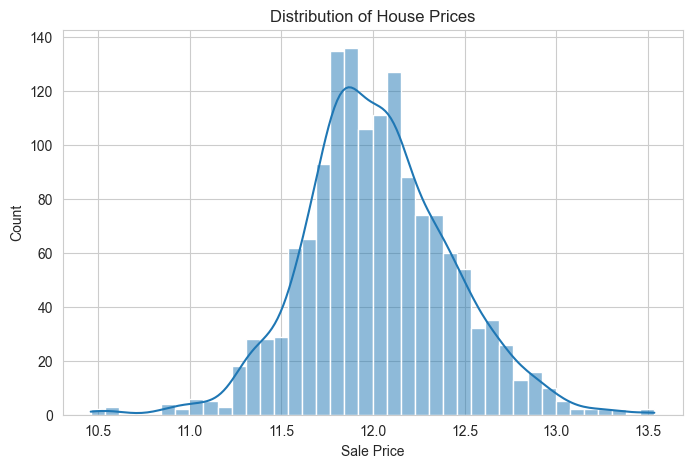

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], bins=40, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Sale Price")
plt.ylabel("Count")

plt.show()

In [21]:
corr = df.corr(numeric_only=True)

sale_corr = (
    corr["SalePrice"]
    .sort_values(ascending=False)
)

display(sale_corr)

SalePrice                 1.000000
BathQualityInteraction    0.819640
OverallQual               0.817185
LuxuryScore               0.807407
TotalArea                 0.777297
GrLivArea                 0.700927
TotalFinishedSF           0.698492
ExterQual                 0.678840
TotalBathrooms            0.673011
KitchenQual               0.667893
KitchenPremium            0.666723
GarageArea                0.650888
RoomDensity               0.636987
BsmtQual                  0.615804
TotalBsmtSF               0.612134
HouseAgeBin               0.608107
OverallScore              0.606873
GarageEra                 0.606337
1stFlrSF                  0.596981
FullBath                  0.594771
YearBuilt                 0.586570
ExteriorScore             0.586472
YearRemodAdd              0.565608
FireplaceQuNum            0.546362
FireplaceParameter        0.542288
BasementScore             0.539652
TotRmsAbvGrd              0.534422
Foundation_PConc          0.530840
HeatingQC           

# Top 15 correlated features

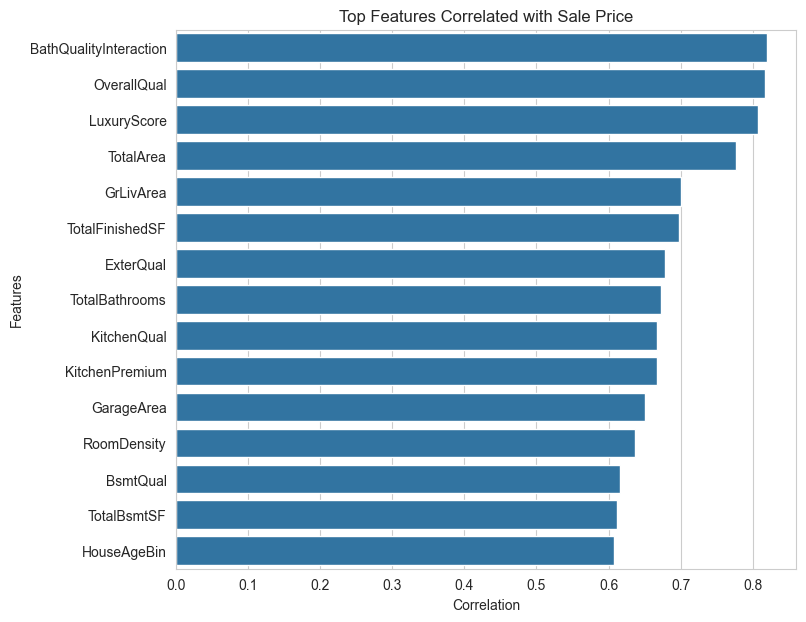

In [26]:
top_corr = sale_corr[1:16]

plt.figure(figsize=(8,7))

sns.barplot(
    x=top_corr.values,
    y=top_corr.index
)

plt.title("Top Features Correlated with Sale Price")
plt.xlabel("Correlation")
plt.ylabel("Features")

plt.show()

## Correlation Heatmap

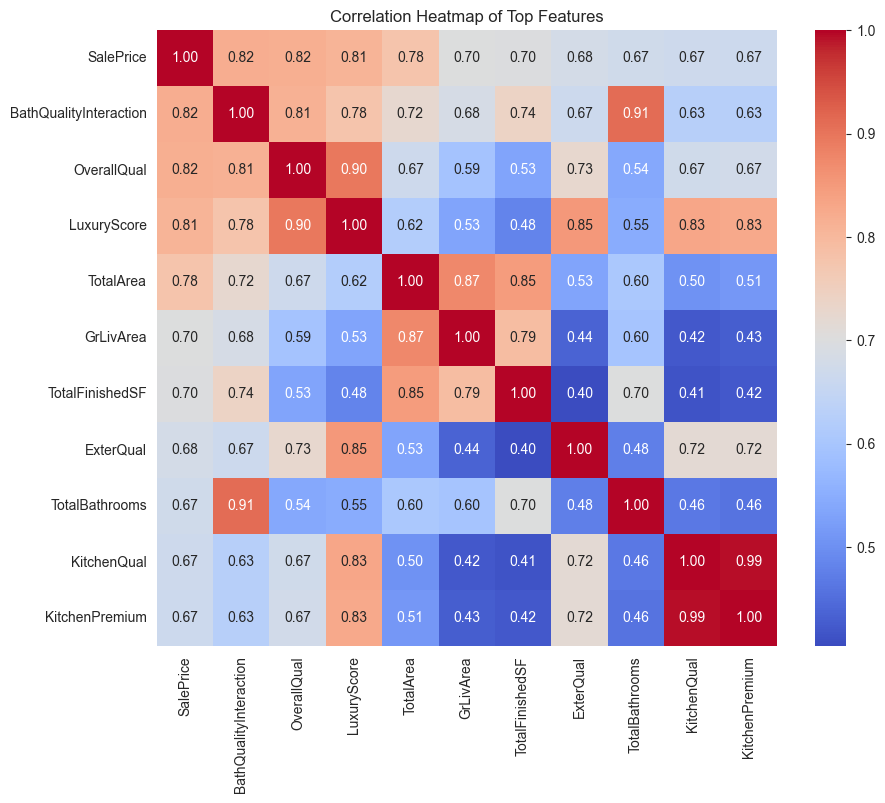

In [28]:
top_features = sale_corr.abs().sort_values(ascending=False).head(11).index

plt.figure(figsize=(10,8))

sns.heatmap(
    df[top_features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Top Features")

plt.show()

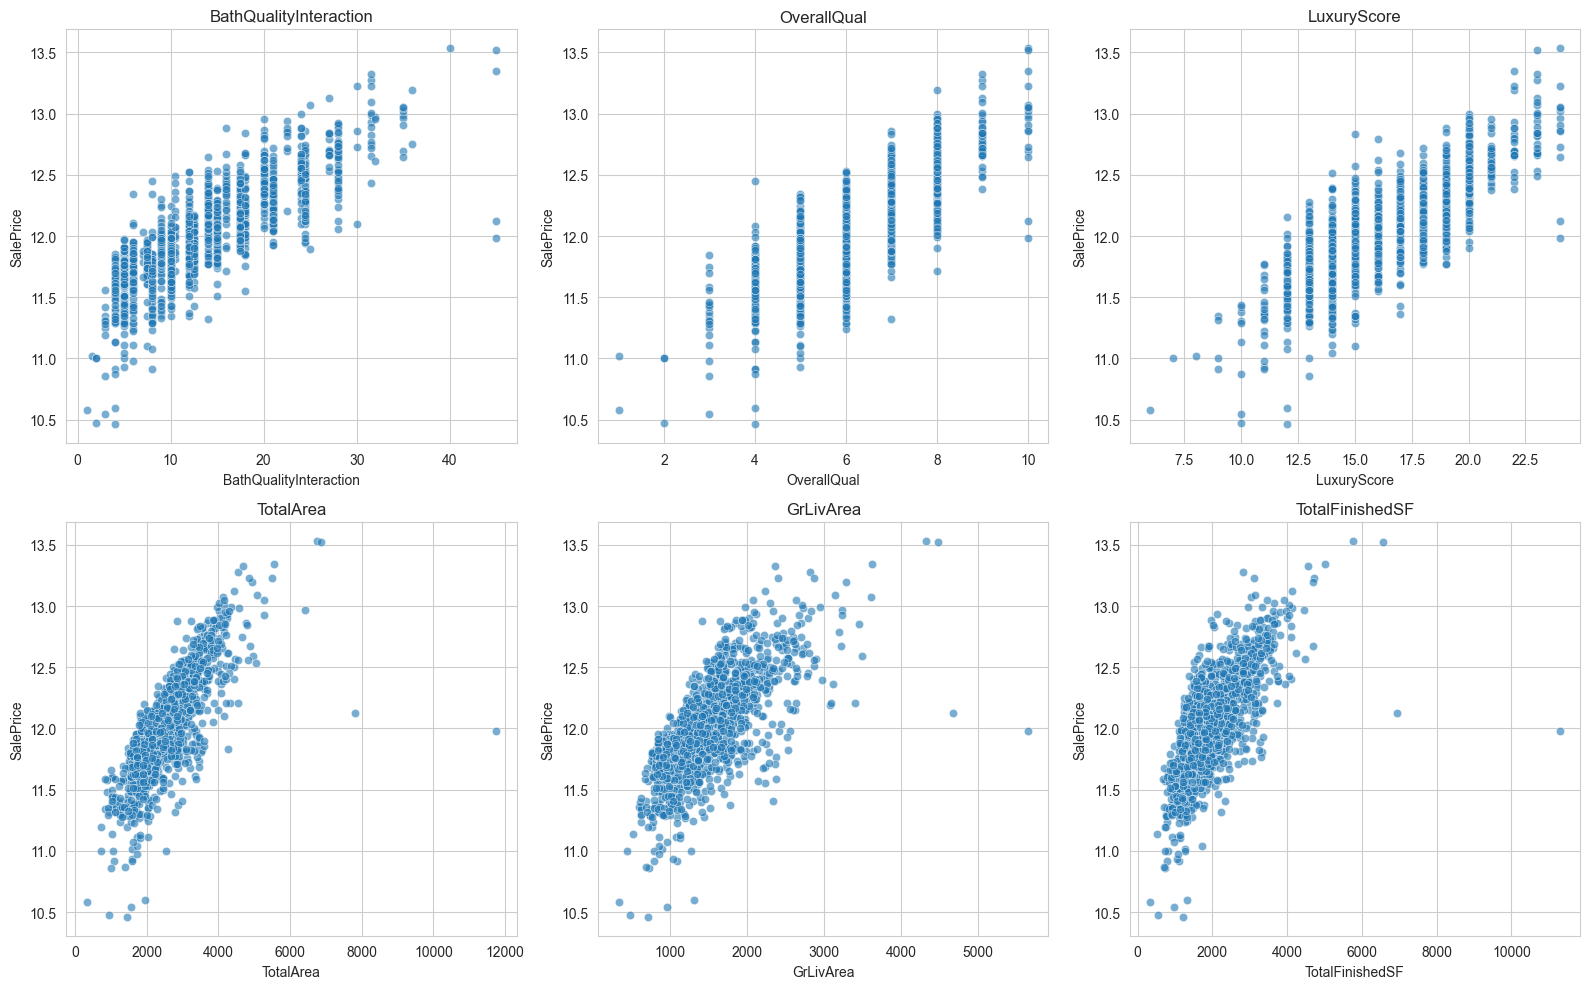

In [33]:
# Get top 6 correlated features (excluding SalePrice itself)
important_features = (
    df.corr(numeric_only=True)["SalePrice"]
    .drop("SalePrice")
    .abs()
    .sort_values(ascending=False)
    .head(6)
    .index
)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, feature in zip(axes.flatten(), important_features):

    sns.scatterplot(
        data=df,
        x=feature,
        y="SalePrice",
        alpha=0.6,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.show()

# Feature Importance

In [36]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)

model.fit(X, y)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

display(importance.head(10))

,Feature,Importance
199,BathQualityInteraction,0.489014
190,TotalArea,0.164675
191,TotalFinishedSF,0.077049
8,OverallQual,0.043814
216,LuxuryScore,0.029052
214,OverallScore,0.028536
40,GarageArea,0.012953
5,LotArea,0.009164
27,1stFlrSF,0.007222
23,TotalBsmtSF,0.006848


# Top 10 most important features

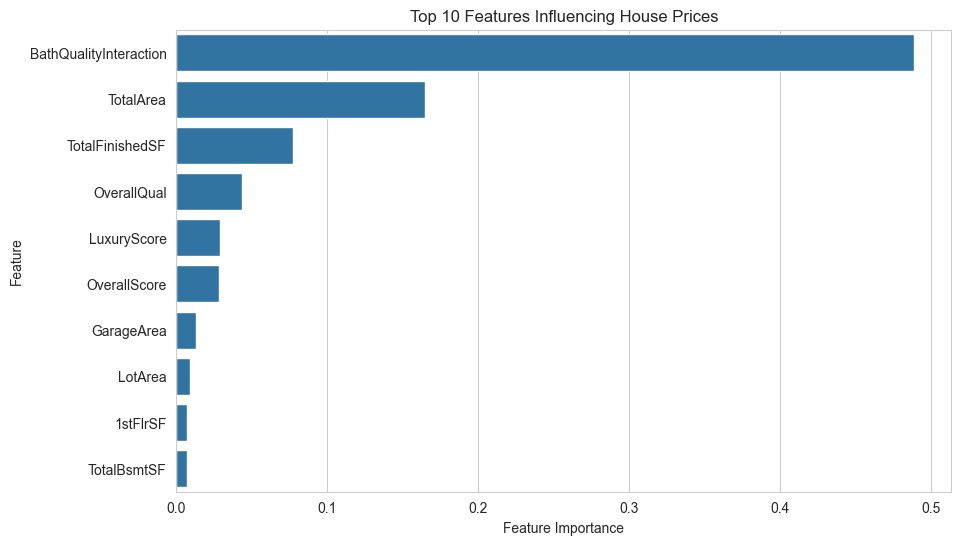

In [39]:
top10 = importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Features Influencing House Prices")

plt.xlabel("Feature Importance")

plt.ylabel("Feature")

plt.show()

# Pairplot of top features

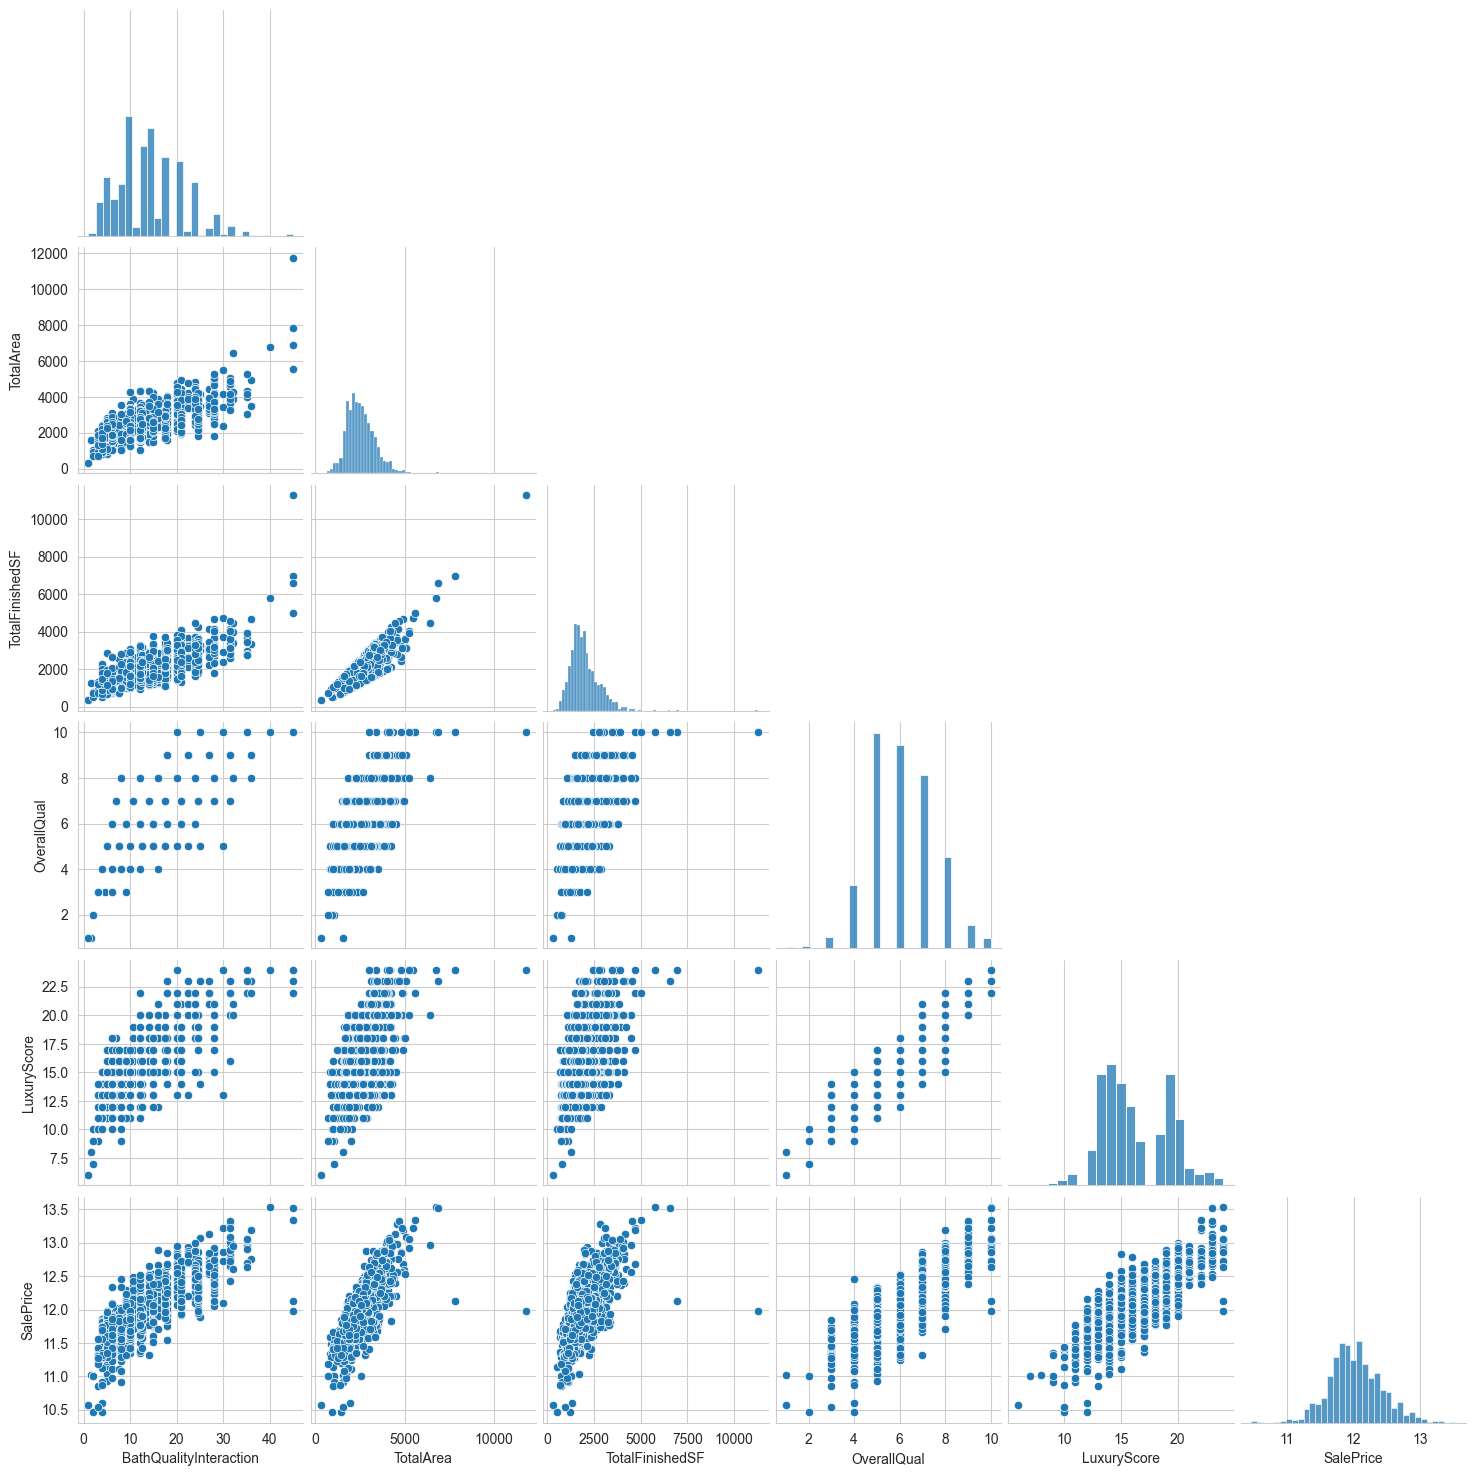

In [43]:
pair_features = list(top10["Feature"][:5])

pair_features.append("SalePrice")

sns.pairplot(
    df[pair_features],
    corner=True
)

plt.show()